In [1]:
import pickle
import pandas as pd
import numpy as np

In [2]:
from pathlib import Path

In [3]:
BATCH = "008"



In [4]:
# Use .expanduser() to turn "~" into "/home/yourusername"
PARQUETS = Path("~/tesi/sarafu/final_simulations").expanduser()
PICKLED = Path("~/papers/adtxns_paper/pickled_data").expanduser()
SARAFU_PICKLED = PICKLED / "sarafu"

FIGURES = Path("~/papers/adtxns_paper/figures/new").expanduser()


In [5]:
with open(SARAFU_PICKLED / "sarafu.pkl", "rb") as f:
    sarafu = pickle.load(f)

In [6]:
metadata = pickle.load(open(PICKLED / BATCH / "metadata.pkl", "rb"))
# metadata

SINGLE SIMULATION 

In [ ]:
# burstiness = 0.75
# spending_noise = 5
# QUERY = f"s == {spending_noise} and burstiness == {burstiness}"

In [7]:
# simu_id = metadata.query(QUERY).iloc[0].simulation_id
# meta_row = metadata.query(QUERY).iloc[0]

# simulation = pickle.load(open(PICKLED / BATCH / f"{simu_id}.pkl", "rb"))


making histograms

In [8]:
from stats_utils import histogram


In [9]:
# keyword = "final_balances"

# # metadata
# s = meta_row["s"]
# b = meta_row["burstiness"]

# # data
# data_sarafu = sarafu["balance_pivot"].iloc[:, -1]
# data_simu   = simulation["balance_pivot"].iloc[:, -1]

# h1 = histogram(data_sarafu)
# h2 = histogram(data_simu)

# # filenames (standard)
# fname_sarafu = f"sarafu__metric={keyword}__s=NA__b=NA"
# fname_simu   = f"simulation__metric={keyword}__s={s}__b={b}"

# # save
# pickle.dump(h1, open(SARAFU_PICKLED / "histograms" / f"{fname_sarafu}.pkl", "wb"))
# pickle.dump(h2, open(PICKLED / BATCH / "histograms" / f"{fname_simu}.pkl", "wb"))


In [10]:
# keyword = "transaction_size"

# # metadata
# s = meta_row["s"]
# b = meta_row["burstiness"]

# # data
# data_sarafu = sarafu["transactions"]["weight"]
# data_simu   = simulation["transactions"]["weight"]

# h1 = histogram(data_sarafu)
# h2 = histogram(data_simu)

# # filenames (standard)
# fname_sarafu = f"sarafu__metric={keyword}__s=NA__b=NA"
# fname_simu   = f"simulation__metric={keyword}__s={s}__b={b}"

# # save
# pickle.dump(h1, open(SARAFU_PICKLED / "histograms" / f"{fname_sarafu}.pkl", "wb"))
# pickle.dump(h2, open(PICKLED / BATCH / "histograms" / f"{fname_simu}.pkl", "wb"))


In [11]:
keyword = "transaction_size"

for s in metadata.s.unique():
    for b in metadata.burstiness.unique():
        QUERY = f"s == {s} and burstiness == {b}"
        meta_row = metadata.query(QUERY).iloc[0]
        simu_id = meta_row.simulation_id
        simulation = pickle.load(open(PICKLED / BATCH / f"{simu_id}.pkl", "rb"))
        data_simu   = simulation["transactions"]["weight"]
        h2 = histogram(data_simu, log_bin=True)
        fname_simu   = f"simulation__metric={keyword}__s={s}__b={b}"
        pickle.dump(h2, open(PICKLED / BATCH / "histograms" / f"{fname_simu}.pkl", "wb"))



In [12]:
# def func(dataset, observable, keyword, metadata,log_bin=True, nbins=31):
keyword = "final_balances"


for s in metadata.s.unique():
    for b in metadata.burstiness.unique():
        QUERY = f"s == {s} and burstiness == {b}"
        meta_row = metadata.query(QUERY).iloc[0]
        simu_id = meta_row.simulation_id
        simulation = pickle.load(open(PICKLED / BATCH / f"{simu_id}.pkl", "rb"))
        data_simu   = simulation["balance_pivot"].iloc[:, -1]
        h2 = histogram(data_simu)
        fname_simu   = f"simulation__metric={keyword}__s={s}__b={b}"
        pickle.dump(h2, open(PICKLED / BATCH / "histograms" / f"{fname_simu}.pkl", "wb"))

# func("agents","")

VARYING THE SIMULATION (SELECT JUST burstiness or s)

In [ ]:
# QUERY = f"burstiness == {burstiness}"

In [ ]:
# meta_slice = metadata.query(QUERY)
# meta_slice

,s,burstiness,simulation_id,sprate_type,sprate_params,inbal_type,inbal_params,activity_type,activity_params,attractivity_type,attractivity_params,N,T,D,decimals,SIZE_SCALE,LENGTH_SCALE,MEAN_IET,copula_type,copula_param
3,1,1.0,3,uniform,"(0, 1)",constant,"(1000,)",powlaw,"(1.85, 1, 1838)",powlaw,"(1.87, 1, 2118)",25000,3000000,0.06864,3,1,6,43706315,joe,3.15
8,5,1.0,8,uniform,"(0, 1)",constant,"(1000,)",powlaw,"(1.85, 1, 1838)",powlaw,"(1.87, 1, 2118)",25000,3000000,0.06864,3,1,6,43706315,joe,3.15
13,10,1.0,13,uniform,"(0, 1)",constant,"(1000,)",powlaw,"(1.85, 1, 1838)",powlaw,"(1.87, 1, 2118)",25000,3000000,0.06864,3,1,6,43706315,joe,3.15
18,20,1.0,18,uniform,"(0, 1)",constant,"(1000,)",powlaw,"(1.85, 1, 1838)",powlaw,"(1.87, 1, 2118)",25000,3000000,0.06864,3,1,6,43706315,joe,3.15
23,50,1.0,23,uniform,"(0, 1)",constant,"(1000,)",powlaw,"(1.85, 1, 1838)",powlaw,"(1.87, 1, 2118)",25000,3000000,0.06864,3,1,6,43706315,joe,3.15
28,100,1.0,28,uniform,"(0, 1)",constant,"(1000,)",powlaw,"(1.85, 1, 1838)",powlaw,"(1.87, 1, 2118)",25000,3000000,0.06864,3,1,6,43706315,joe,3.15
33,250,1.0,33,uniform,"(0, 1)",constant,"(1000,)",powlaw,"(1.85, 1, 1838)",powlaw,"(1.87, 1, 2118)",25000,3000000,0.06864,3,1,6,43706315,joe,3.15


In [ ]:
keyword = "spending_parameters"

# data
data_sarafu = sarafu["agents"]["mean_frac_out"]
h1 = histogram(data_sarafu, log_bin=False,num_bins=51)
fname_sarafu = f"sarafu__metric={keyword}__s=NA__b=NA"

pickle.dump(h1, open(SARAFU_PICKLED / "histograms" / f"{fname_sarafu}.pkl", "wb"))




In [55]:

for s in metadata.s.unique():
    for b in metadata.burstiness.unique():
        QUERY = f"s == {s} and burstiness == {b}"
        meta_row = metadata.query(QUERY).iloc[0]
        simu_id = meta_row.simulation_id
        simulation = pickle.load(open(PICKLED / BATCH / f"{simu_id}.pkl", "rb"))
        data_simu   = simulation["agents"]["mean_frac_out"]
        h2 = histogram(data_simu, log_bin=False,num_bins=51 )
        fname_simu   = f"simulation__metric={keyword}__s={s}__b={b}"
        pickle.dump(h2, open(PICKLED / BATCH / "histograms" / f"{fname_simu}.pkl", "wb"))

# data_simu   = simulation["agents"]["mean_frac_out"]

# h2 = histogram(data_simu)

# # filenames (standard)
# fname_simu   = f"simulation__metric={keyword}__s={s}__b={b}"

# # save
# pickle.dump(h2, open(PICKLED / BATCH / "histograms" / f"{fname_simu}.pkl", "wb"))


In [56]:
keyword = "spending_fraction"

# data
data_sarafu = sarafu["transactions"]["frac_out"]
h1 = histogram(data_sarafu, log_bin=False,num_bins=51)
fname_sarafu = f"sarafu__metric={keyword}__s=NA__b=NA"

pickle.dump(h1, open(SARAFU_PICKLED / "histograms" / f"{fname_sarafu}.pkl", "wb"))




In [ ]:
# spending fractions
for s in metadata.s.unique():
    for b in metadata.burstiness.unique():
        QUERY = f"s == {s} and burstiness == {b}"
        meta_row = metadata.query(QUERY).iloc[0]
        simu_id = meta_row.simulation_id
        simulation = pickle.load(open(PICKLED / BATCH / f"{simu_id}.pkl", "rb"))
        data_simu   = simulation["transactions"]["frac_out"]
        h2 = histogram(data_simu, log_bin=False,num_bins=51)
        fname_simu   = f"simulation__metric={keyword}__s={s}__b={b}"
        pickle.dump(h2, open(PICKLED / BATCH / "histograms" / f"{fname_simu}.pkl", "wb"))



In [13]:
sarafu["agents"].columns

Index(['crid', 'tx_in', 'vol_in', 'mean_earn', 'median_earn', 'max_earn',
       'min_earn', 'mean_frac_in', 'median_frac_in', 'max_frac_in',
       'min_frac_in', 'in_deg', 'first_txns_in', 'tx_out', 'vol_out',
       'mean_exp', 'median_exp', 'max_exp', 'min_exp', 'mean_frac_out',
       'median_frac_out', 'max_frac_out', 'min_frac_out', 'out_deg',
       'first_txns_out'],
      dtype='object')

In [14]:
keyword = "out_degree"

# data
data_sarafu = sarafu["agents"]["out_deg"]
h1 = histogram(data_sarafu, log_bin=False,num_bins=51)
fname_sarafu = f"sarafu__metric={keyword}__s=NA__b=NA"

pickle.dump(h1, open(SARAFU_PICKLED / "histograms" / f"{fname_sarafu}.pkl", "wb"))



for s in metadata.s.unique():
    for b in metadata.burstiness.unique():
        QUERY = f"s == {s} and burstiness == {b}"
        meta_row = metadata.query(QUERY).iloc[0]
        simu_id = meta_row.simulation_id
        simulation = pickle.load(open(PICKLED / BATCH / f"{simu_id}.pkl", "rb"))
        data_simu   = simulation["agents"]["out_deg"]
        h2 = histogram(data_simu, log_bin=False,num_bins=51 )
        fname_simu   = f"simulation__metric={keyword}__s={s}__b={b}"
        pickle.dump(h2, open(PICKLED / BATCH / "histograms" / f"{fname_simu}.pkl", "wb"))


In [15]:
keyword = "in_degree"

# data
data_sarafu = sarafu["agents"]["in_deg"]
h1 = histogram(data_sarafu, log_bin=False,num_bins=51)
fname_sarafu = f"sarafu__metric={keyword}__s=NA__b=NA"

pickle.dump(h1, open(SARAFU_PICKLED / "histograms" / f"{fname_sarafu}.pkl", "wb"))



for s in metadata.s.unique():
    for b in metadata.burstiness.unique():
        QUERY = f"s == {s} and burstiness == {b}"
        meta_row = metadata.query(QUERY).iloc[0]
        simu_id = meta_row.simulation_id
        simulation = pickle.load(open(PICKLED / BATCH / f"{simu_id}.pkl", "rb"))
        data_simu   = simulation["agents"]["in_deg"]
        h2 = histogram(data_simu, log_bin=False,num_bins=51 )
        fname_simu   = f"simulation__metric={keyword}__s={s}__b={b}"
        pickle.dump(h2, open(PICKLED / BATCH / "histograms" / f"{fname_simu}.pkl", "wb"))


In [13]:
sarafu['agents']['tx_out'].nlargest(20)

1409     1838.0
11388    1827.0
10218    1737.0
11387    1621.0
9449     1597.0
10399    1578.0
10219    1384.0
17140    1308.0
9233     1194.0
13256    1091.0
10472    1057.0
13157    1034.0
12992    1008.0
10467    1002.0
10675     996.0
13158     890.0
5626      872.0
10076     855.0
23653     785.0
11648     765.0
Name: tx_out, dtype: float64

In [ ]:
from preprocessing_utils import START
from tqdm import tqdm
from stats_utils import histogram
import matplotlib.pyplot as plt

In [9]:
most_active_sarafu = sarafu['agents'].nlargest(50, columns = 'tx_out')[['crid','tx_out']]

In [ ]:
most_active_sarafu.head()

,crid,tx_out
1409,4076,1838.0
11388,17553,1827.0
10218,16098,1737.0
11387,17552,1621.0
9449,15187,1597.0


In [27]:
# df = sarafu['transactions'].loc[sarafu['transactions'].source.isin(most_active_sarafu.crid)]
df = sarafu['transactions']

# df = sarafu.transactions
time_from_start = (df.groupby('source').first().date-START)
# print(time_from_start)
iets={}
for idx, group in tqdm(df.groupby('source'),colour='green'):
    # print(idx)
    # print(idx,group.date.diff().fillna(time_from_start.loc[idx]).dt.total_seconds().head(2))
    iets[idx] = (group.date.diff().fillna(time_from_start.loc[idx]).dt.total_seconds().values)



100%|██████████| 23654/23654 [00:43<00:00, 546.25it/s] 


[]

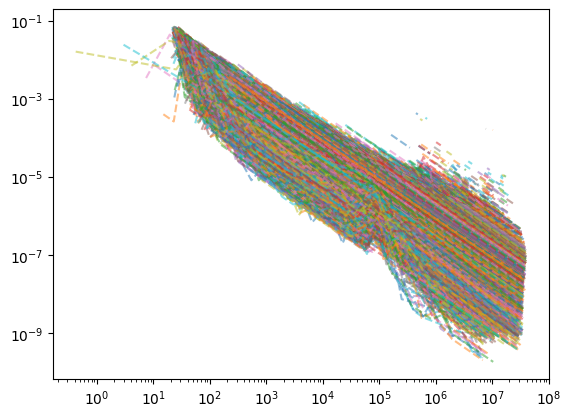

In [37]:
hs = {}
for k in iets:
    h = histogram(iets[k])
    plt.plot(h[0],h[1],ls='--',alpha=0.5)
    hs[k] = h


plt.loglog()

In [45]:
pickle.dump(hs, open(SARAFU_PICKLED / "histograms" / f"inter_event_times_all.pkl", "wb"))

[]

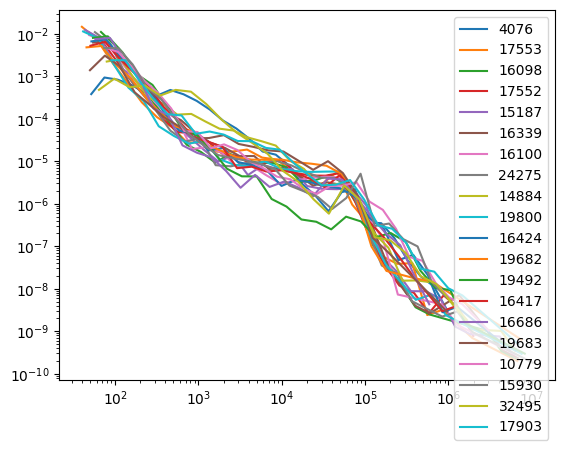

In [44]:
for k in most_active_sarafu.head(20).crid:
    h = hs[k]
    plt.plot(h[0],h[1], label = k )

plt.legend()

plt.loglog()


In [24]:
most_active_sarafu

,crid,tx_out
1409,4076,1838.0
11388,17553,1827.0
10218,16098,1737.0
11387,17552,1621.0
9449,15187,1597.0
10399,16339,1578.0
10219,16100,1384.0
17140,24275,1308.0
9233,14884,1194.0
13256,19800,1091.0


In [22]:
d = iets.copy()

ordered = dict(
    sorted(d.items(), key=lambda item: len(item[1]), reverse=True)
)

d.keys()
# pickle(iets

dict_keys([1, 3, 6, 9, 12, 13, 15, 26, 29, 30, 31, 33, 45, 47, 49, 51, 60, 61, 64, 69, 71, 76, 79, 80, 98, 99, 145, 172, 179, 197, 200, 201, 223, 228, 229, 234, 235, 294, 316, 327, 340, 349, 356, 366, 438, 483, 496, 497, 500, 511, 517, 542, 568, 583, 594, 640, 654, 655, 657, 659, 660, 664, 665, 676, 685, 688, 704, 718, 722, 724, 727, 728, 730, 734, 735, 737, 747, 749, 751, 752, 754, 756, 764, 766, 767, 768, 769, 771, 773, 776, 778, 782, 788, 789, 792, 793, 794, 797, 801, 816, 819, 820, 824, 827, 828, 829, 830, 833, 835, 839, 840, 850, 876, 901, 910, 912, 914, 915, 916, 917, 922, 924, 928, 936, 961, 979, 1004, 1006, 1009, 1016, 1031, 1032, 1053, 1089, 1096, 1098, 1099, 1102, 1110, 1115, 1121, 1130, 1132, 1133, 1137, 1138, 1143, 1146, 1176, 1180, 1185, 1186, 1189, 1190, 1192, 1198, 1200, 1201, 1205, 1216, 1218, 1221, 1223, 1225, 1236, 1251, 1253, 1256, 1260, 1264, 1271, 1272, 1273, 1282, 1283, 1289, 1290, 1296, 1298, 1303, 1307, 1314, 1327, 1328, 1329, 1331, 1335, 1350, 1351, 1353, 1357,

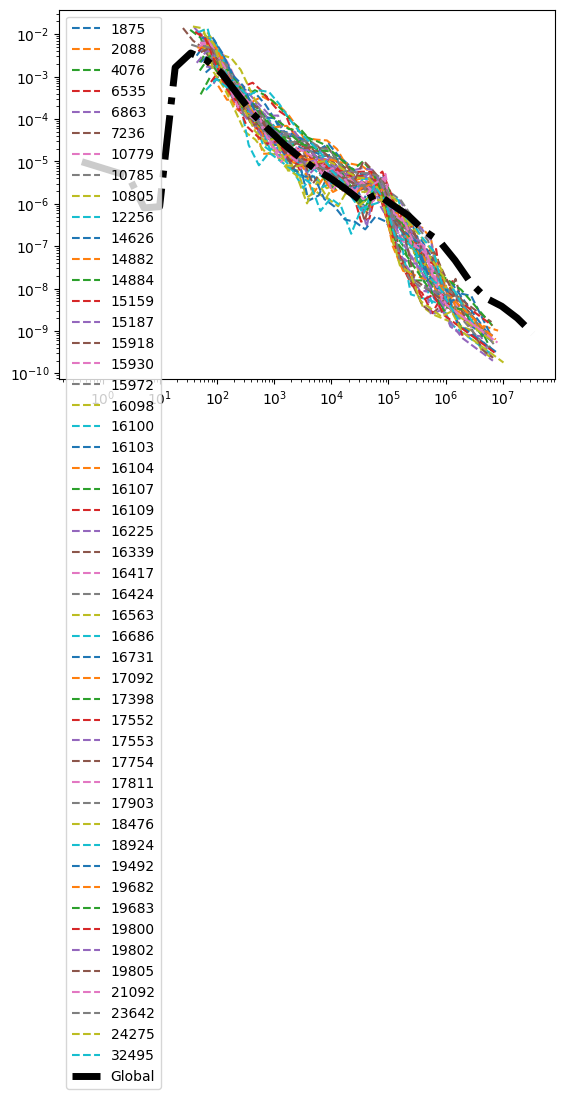

In [57]:
logx = 1
logy = 1
for user in iets:
    h = histogram(iets[user])
    plt.plot(h[0],h[1],ls='--',label=user)

h = histogram(sarafu['iet'])
plt.plot(h[0],h[1],label='Global', ls='-.', color='k', lw=5)
if logx:
    plt.xscale('log')
if logy:
    plt.yscale('log')

plt.legend()
